---
skip_execution: true
---

# 1D Poisson problem with TV denoising using MYULA

This script provides code for setting up a Bayesian inverse problem of inferring a conductivity field from potential u measurements everywhere in a 1D domain. The map from the log conductivity 𝜿 to the measurements is governed by the 1D Poisson equation with specified Dirichlet boundary conditions and source term $f(x)=10$. 

$$ \nabla \cdot \left( e^{\kappa(x)} \nabla u(x) \right) = f(x) \;\; \text{ in } \;\;\Omega = (0,1)^2 $$

We have to setups for the Bayesian inverse problem:
- one with GMRF prior for the conductivity field and we use ULA for sampling, and
- one with TV denoising for the conductivity field and we use MYULA for sampling.


Additional resources for solving Poisson problem using CUQIpy-FEniCS:
- [CUQI book](https://cuqi-dtu.github.io/CUQI-Book/chapter04/Plugins/CUQIpy-FEniCS/poisson_2D_fenics.html)
- [Documentation](https://cuqi-dtu.github.io/CUQIpy-FEniCS/api/_autosummary/cuqipy_fenics.testproblem/cuqipy_fenics.testproblem.FEniCSPoisson2D.html#cuqipy_fenics.testproblem.FEniCSPoisson2D)
- [CUQIpy paper part II](https://arxiv.org/abs/2305.16951)



## Imports

In [1]:
from cuqi.problem import BayesianProblem
from cuqi.distribution import Gaussian
from cuqi.sampler import  ULA
from cuqi.samples import Samples
from cuqi.implicitprior import RestorationPrior, MoreauYoshidaPrior
from cuqipy_fenics.testproblem import FEniCSPoisson2D
from pde_myula_utils import (sample_in_batches,
                             plot_figure_12,
                             get_samples_at_line)
import numpy as np
import cuqi
import cuqipy_fenics
import dolfin as dl
import matplotlib.pyplot as plt
from skimage.restoration import denoise_tv_chambolle
import ufl

# Set logging level of dl
dl.set_log_level(dl.LogLevel.ERROR)

/Users/amal/opt/miniconda3/envs/fenics_clean/lib/python3.10/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


## Set up CUQIpy PDE object

In [2]:
n = 80
x_true = np.ones(n)*-1
x_true[int(n/3):2*int(n/3)] = -0.5
Ns = 10000
Nt = 1
Nb = 0
source_signal =  10

def u_boundary(x, on_boundary):
    return on_boundary and  ((x[0] > 1-dl.DOLFIN_EPS) )

def form(m,u,p):
    return ufl.exp(m)*ufl.inner(ufl.grad(u), ufl.grad(p))*ufl.dx\
          - dl.Constant(source_signal)*p*ufl.dx
        
mesh = dl.IntervalMesh(n-1, 0, 1)

solution_function_space = dl.FunctionSpace(mesh, 'Lagrange', 1)
parameter_function_space = dl.FunctionSpace(mesh, 'Lagrange', 1)

dirichlet_bc_expression = dl.Expression("right_bc*(x[0]>endpoint-eps)", eps=dl.DOLFIN_EPS, endpoint=1, left_bc=0, right_bc=1, degree=1)
        
dirichlet_bc = [dl.DirichletBC(solution_function_space, dirichlet_bc_expression, u_boundary)]
adjoint_dirichlet_bc = [dl.DirichletBC(
            solution_function_space, dl.Constant(0), u_boundary)]

PDE = cuqipy_fenics.pde.SteadyStateLinearFEniCSPDE(
            form, mesh, solution_function_space, parameter_function_space, dirichlet_bc, adjoint_dirichlet_bc)


## Set up CUQIpy PDE model

In [3]:
domain_geometry = cuqipy_fenics.geometry.FEniCSContinuous(parameter_function_space)

range_geometry = cuqipy_fenics.geometry.FEniCSContinuous(solution_function_space)
        
model = cuqi.model.PDEModel(PDE,range_geometry,domain_geometry)



## Without TV denoising
### Prior (GMRF), data distribution and posterior

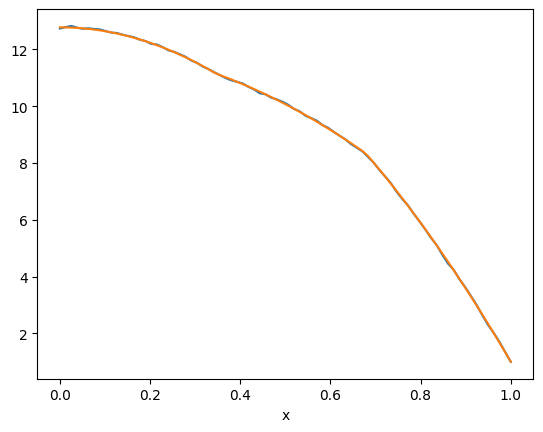

In [4]:
# Create prior
pr_mean = np.zeros(domain_geometry.par_dim)
x = cuqi.distribution.GMRF(pr_mean,25) 

exactSolution = cuqi.array.CUQIarray(x_true, geometry=domain_geometry)

# Generate exact data
b_exact = model.forward(exactSolution.funvals,is_par=False)

noise = 0.02

# Create likelihood
y = cuqi.distribution.Gaussian(
    mean=model(x), cov=noise**2*np.eye(range_geometry.par_dim), geometry=range_geometry)
data = y(x=exactSolution.parameters).sample()

plt.figure()
data.plot()
b_exact_cuqi_array = cuqi.array.CUQIarray(b_exact, geometry=domain_geometry)
b_exact_cuqi_array.plot()

posterior = cuqi.distribution.JointDistribution(x, y)(y=data)

### Sample the posterior with ULA

In [5]:

initial_point_ula = np.ones(n)*-0.75
scale_ula = 5e-6
sampler_ula = cuqi.sampler.ULA(posterior, initial_point=initial_point_ula, scale=scale_ula)
sampler_ula.warmup(Nb)
sampler_ula.sample(Ns, Nt)

# Sample from the posterior
samples_ula = sampler_ula.get_samples()



Warmup: : 0it [00:00, ?it/s]
Sample: 100%|██████████| 10000/10000 [09:00<00:00, 18.50it/s, acc rate: 100.00%]


(-1.4, 0.0)

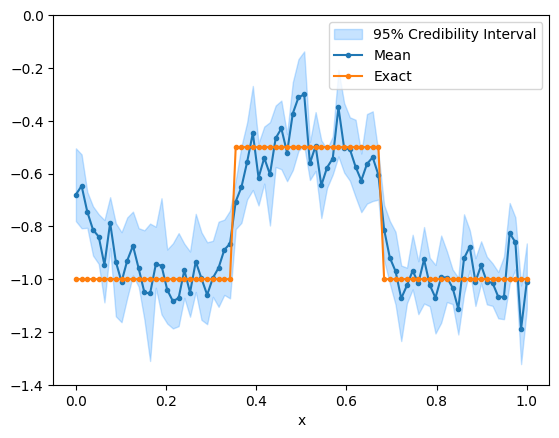

: 

In [ ]:
# Switch geometry to 1D for plotting and plot the credible intervals
samples_ula.geometry = cuqi.geometry.Continuous1D(np.flip(mesh.coordinates()[:,0]))
samples_ula.burnthin(Nb).plot_ci(95, exact=exactSolution, linestyle='-', marker='.')
plt.ylim(-1.4,0)

## With TV denoising
### Prior (TV), data distribution and posterior

In [7]:
TV_weight_factor =50
initial_point_myula = np.ones(n)*-0.75

def restore_TV(x, restoration_strength=None):

    # Apply denoising on the grid representation of the function
    denoised_image = denoise_tv_chambolle(x,
        weight=TV_weight_factor*restoration_strength,
        max_num_iter=100)
    return  denoised_image, None

restorator = RestorationPrior(
        restore_TV,
        geometry=model.domain_geometry
    )

restoration_strength =0.5 * noise**2 #10*0.5 * noise**2
x_tv = MoreauYoshidaPrior(restorator, smoothing_strength=restoration_strength)
y_tv = Gaussian(model(x_tv), noise**2, geometry=model.range_geometry)
posterior_tv = cuqi.distribution.JointDistribution(y_tv, x_tv)(y_tv=data)

scale_myula =5e-6
sampler_myula = ULA(posterior_tv, scale=scale_myula, initial_point=initial_point_myula)


sampler_myula.sample(Ns, Nt=Nt)
# Sample from the posterior
samples_myula = sampler_myula.get_samples()



Sample: 100%|██████████| 10000/10000 [08:34<00:00, 19.45it/s, acc rate: 100.00%]


(-1.4, 0.0)

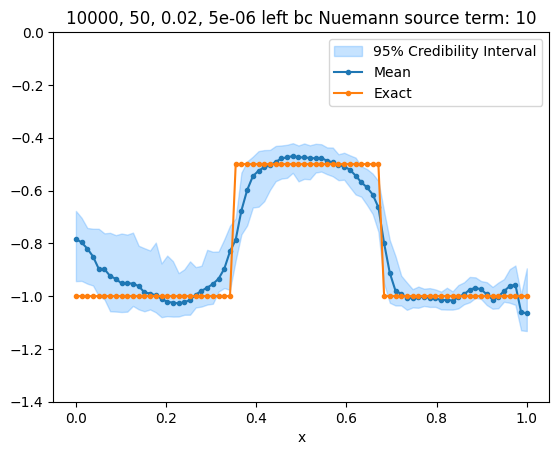

In [15]:
# switch geometry to 1D for plotting and plot the credible intervals
samples_myula.geometry = cuqi.geometry.Continuous1D(np.flip(mesh.coordinates()[:,0]))
samples_myula.burnthin(Nb).plot_ci(95, exact=exactSolution, linestyle='-', marker='.')
plt.title(str(Ns)+", "+str(TV_weight_factor)+", "+str(noise)+", "+str(scale_myula)+" left bc Nuemann"+ " source term: "+str(source_signal))
plt.ylim(-1.4,0)

array([[<Axes: title={'center': 'v0'}>, <Axes: title={'center': 'v0'}>]],
      dtype=object)

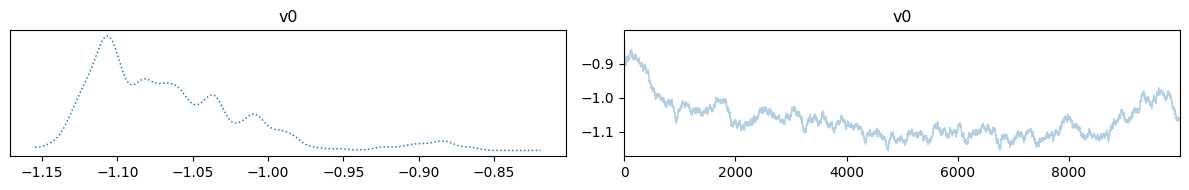

In [9]:
samples_myula.plot_trace([0])